/var/folders/qw/v1v41zkx3w53m8bcz3ng_tqw0000gn/T/ipykernel_10223/45896055.py:72: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(x_vals, y_fourier, 'r--',label=f'Série de Fourier (N={N_termos})', color='blue', linewidth=2)


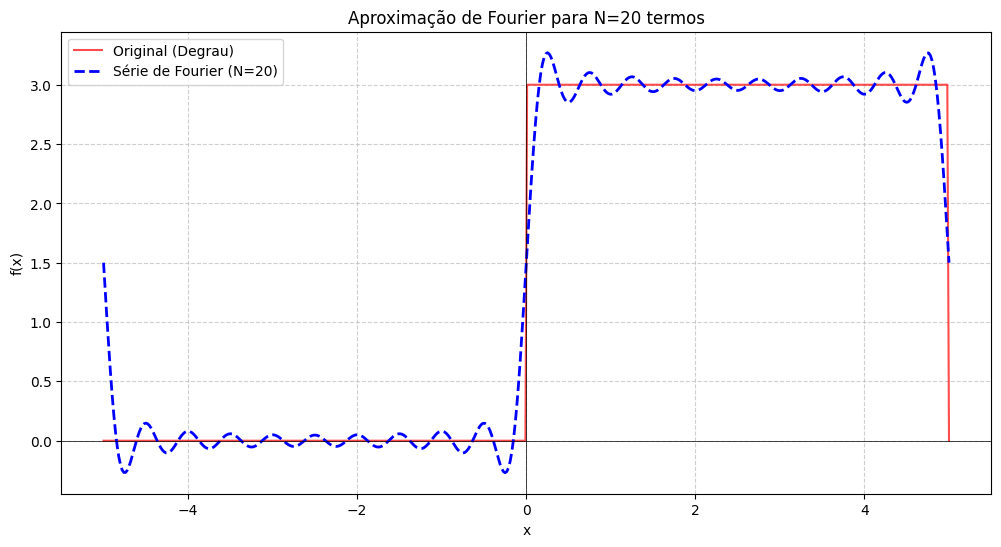

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# ==========================================
# 1. Parâmetros Físicos 
# ==========================================
L = 5               # Semi-período
N_termos = 20       # Aumentado para ver melhor a convergência

# ==========================================
# 2. Condição Inicial f(x)
# ==========================================
# Definindo uma função degrau quadrada (Square Wave)
def f(x):
    if -L < x < 0:
        return 0
    elif 0 < x < L:
        return 3
    else:
        return 0

# ==========================================
# 3. Pré-cálculo dos Coeficientes
# ==========================================
def calcula_an(n, L):
    integrando = lambda x: f(x) * np.cos((n * np.pi * x) / L)
    integral, _ = quad(integrando, -L, L)
    return (1.0 / L) * integral

def calcula_bn(n, L):
    integrando = lambda x: f(x) * np.sin((n * np.pi * x) / L)
    integral, _ = quad(integrando, -L, L)
    return (1.0 / L) * integral

# Cálculo do termo fundamental a0
a0, _ = quad(f, -L, L)
a0 = (1.0 / (2 * L)) * a0

an_values = [calcula_an(n, L) for n in range(1, N_termos + 1)]
bn_values = [calcula_bn(n, L) for n in range(1, N_termos + 1)]

# ==========================================
# 4. Solução Matemática u(x,t)
# ==========================================
def fourier(x, L, N, a0, coeficientes_a, coeficientes_b):
    # Começamos a soma pelo termo a0
    soma = np.full_like(x, a0, dtype=float) 
    
    for n in range(1, N + 1):
        an = coeficientes_a[n-1]
        bn = coeficientes_b[n-1]
        termo = an * np.cos((n * np.pi * x) / L) + bn * np.sin((n * np.pi * x) / L)
        soma += termo
    return soma

# ==========================================
# 5. Simulação e Gráficos
# ==========================================
# Aumentado para 500 pontos para suavidade
x_vals = np.linspace(-L, L, 500)

plt.figure(figsize=(12, 6))

# Calculando a aproximação
y_fourier = fourier(x_vals, L, N_termos, a0, an_values, bn_values)

# Plotando a função original
y_original = np.array([f(val) for val in x_vals])

plt.plot(x_vals, y_original, label='Original (Degrau)', alpha=0.7, color='red')
plt.plot(x_vals, y_fourier, 'r--',label=f'Série de Fourier (N={N_termos})', color='blue', linewidth=2)

plt.title(f'Aproximação de Fourier para N={N_termos} termos')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

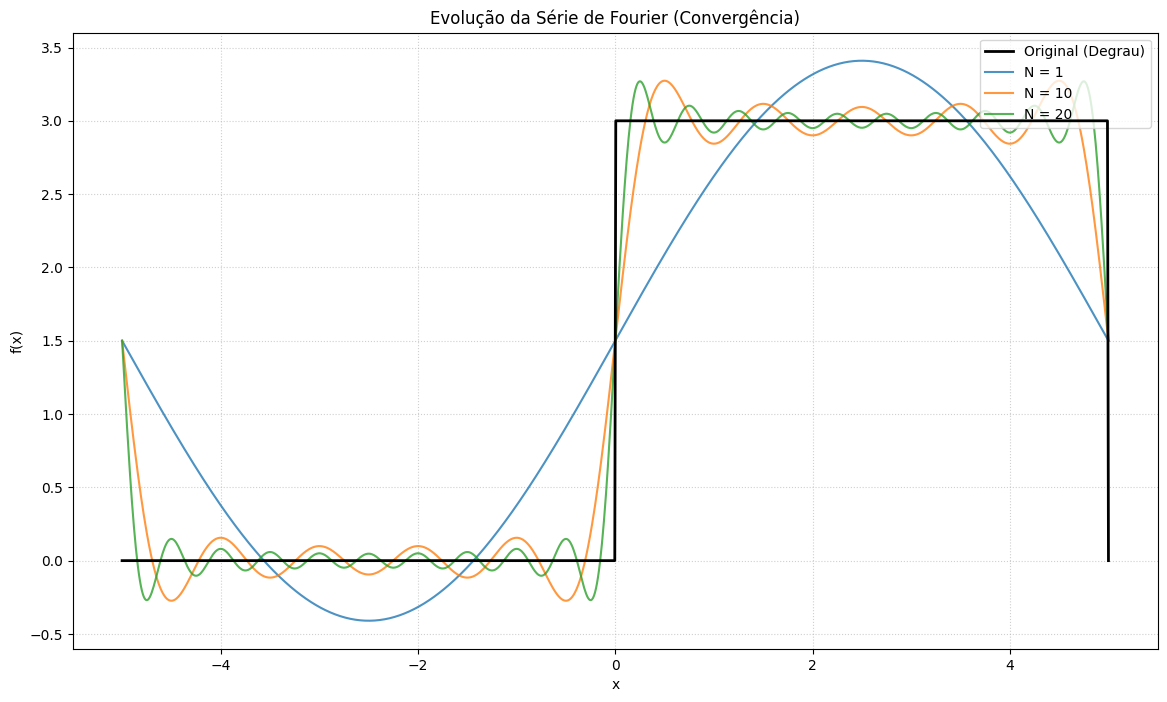

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# ==========================================
# 1. Parâmetros Físicos 
# ==========================================
L = 5
valores_n = [1, 10, 20] # Valores solicitados

# ==========================================
# 2. Condição Inicial f(x)
# ==========================================
def f(x):
    if -L < x < 0:
        return 0
    elif 0 < x < L:
        return 3
    else:
        return 0 # Valor médio na descontinuidade

# ==========================================
# 3. Funções de Cálculo
# ==========================================
def calcula_an(n, L):
    integrando = lambda x: f(x) * np.cos((n * np.pi * x) / L)
    return (1.0 / L) * quad(integrando, -L, L)[0]

def calcula_bn(n, L):
    integrando = lambda x: f(x) * np.sin((n * np.pi * x) / L)
    return (1.0 / L) * quad(integrando, -L, L)[0]

# Pré-calculando o a0 (valor médio da função)
a0 = (1.0 / (2 * L)) * quad(f, -L, L)[0]

# ==========================================
# 4. Simulação e Plotagem
# ==========================================
x_vals = np.linspace(-L, L, 1000)
y_original = np.array([f(val) for val in x_vals])

plt.figure(figsize=(14, 8))
plt.plot(x_vals, y_original, color='black', lw=2, label='Original (Degrau)', zorder=10)

# Loop para testar cada N
for N in valores_n:
    # Calculamos os coeficientes necessários para este N
    an_list = [calcula_an(n, L) for n in range(1, N + 1)]
    bn_list = [calcula_bn(n, L) for n in range(1, N + 1)]
    
    # Construção da série
    soma = np.full_like(x_vals, a0)
    for n in range(1, N + 1):
        soma += an_list[n-1] * np.cos((n * np.pi * x_vals) / L) + \
                bn_list[n-1] * np.sin((n * np.pi * x_vals) / L)
    
    plt.plot(x_vals, soma, label=f'N = {N}', alpha=0.8)

plt.title('Evolução da Série de Fourier (Convergência)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()